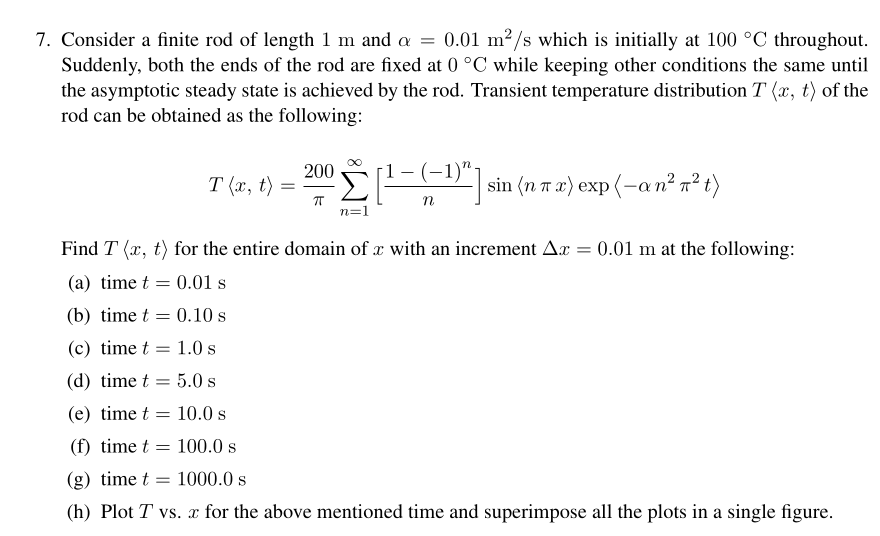

This equation can equivalently be written as 
$\frac {200} {\pi} * \Sigma [\frac{2}{2n -1 } sin((2n-1) \pi x) exp(-\alpha (2n-1)^2 \pi^2 t)]$

(If you don't have a Latex previewer, basically I just turned the n's into 2n-1 to make it a purely decreasing )

Assuming $10^-5$ precision

In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def Tterm(n, x, alpha, t):
    return ((200/np.pi)*(1 - (-1)**n )/n * np.sin(n * np.pi * x) * np.exp(-alpha * n**2 * np.pi**2 * t))
# we're simply following the notation the question provides for now 
def sumTerms(n, x, alpha, t):
    sum = 0
    for i in range(1, n+1): #we want an inclusive range
        sum += Tterm(i, x, alpha, t)
        #print(sum)
    
    return sum



print(Tterm(99, 0.01, 0.01, 0.01))
print(sumTerms(99, 0.03, 0.01, 0.01))


2.5429410289798198e-06
96.61057039539514


We can first compute a list containing all the term precisions at a given t, at every single x value from 0 to 1. 
We then sum up at each x step. 


In [91]:
# for t = 0.01
xSteps = np.arange(0.01, 1.01, 0.01)
precisionList = []
# for each x step, increase n till it satisfies. 
for x in xSteps:
    n = 1
    while Tterm(n, x, 0.01, 0.01) > 0.5 * 10**-5:
        print(Tterm(n, x, 0.01, 0.01))
        n +=1
    else:
        precisionList.append(n)
print(precisionList)


3.9953968136643643
7.986850653043744
11.970422435092734
15.942180855404908
19.89820626793561
23.834594553219418
27.747460971264665
31.63294399532285
35.48720912274925
39.30645265919418
43.08690547239003
46.82483671182976
50.51655749066597
54.15842452619679
57.74684373534607
61.27827378158952
64.74922956982618
68.15628568574664
71.49607977630336
74.7653158679472
77.96076761935532
81.07928150544069
84.11777992950049
87.07326426043252
89.94281779202207
92.72360862137893
95.41289244368338
98.00801526048403
100.50641599887366
102.90562903895906
105.20328664713016
107.39712131272726
109.4849679858003
111.46476621375173
113.33456217475448
115.0925106059383
116.73687662444121
118.26603743952974
119.67848395409717
120.97282225396039
122.1477749834848
123.20218260618006
124.13500454902281
124.94532022937638
125.63232996349491
126.19535575571444
126.63384196755304
126.94735586605869
127.13558805086454
127.19835275952975
127.13558805086454
126.94735586605869
126.63384196755304
126.19535575571443
1

99 terms is considered sufficiently precise. 

In [17]:
T_values = {}

for t in times:
    T_at_t = []
    
    for x in domain:
        T_at_t.append(sumTerms(99, x, 0.01, t))
    
    T_values[t] = np.array(T_at_t)
    


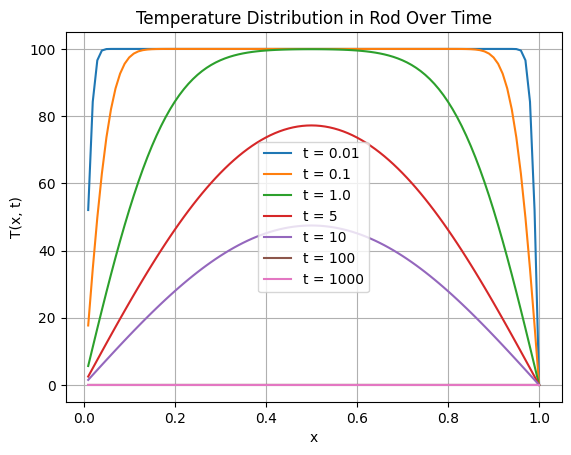

In [ ]:

plt.figure()

for t in times:
    plt.plot(domain, T_values[t], label=f"t = {t}")

plt.xlabel("x")
plt.ylabel("T(x, t)")
plt.title("Temperature Distribution in Rod Over Time")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# finding the required term for 1e-5 precision

precisionTerms = []

# for xi in range(0, 1, 0.01):
#     for (n=1, (Tterm(n, xi, 0.01, times[0]) < 0.5 * 10**-5), n++):
        
i = 0
n=1
for xi in range(1, 1, 1):
    while (Tterm(n, xi/100, 0.01, times[0]) > 0.5* 10**-5):
        n += 1
    else: 
        precisionTerms.append(n)
        n=1


Question 8 is similar enough that the same notebook will do

In [21]:
def Tterm2D(n, x, y):
    return ((200/np.pi) * (1 - (-1)**n) / (n * np.sinh(n * np.pi)) 
            * np.sin(n * np.pi * x) * np.sinh(n * np.pi * y))


def sumTerms2D(n, x, y):
    total = 0
    for i in range(1, n+1):
        total += Tterm2D(i, x, y)
    return total

In [23]:
x_domain = np.linspace(0, 1, 101)
y_domain = np.linspace(0, 1, 101)
T_grid = np.zeros((len(y_domain), len(x_domain)))

for i, y in enumerate(y_domain):
    for j, x in enumerate(x_domain):
        T_grid[i, j] = sumTerms2D(99, x, y)

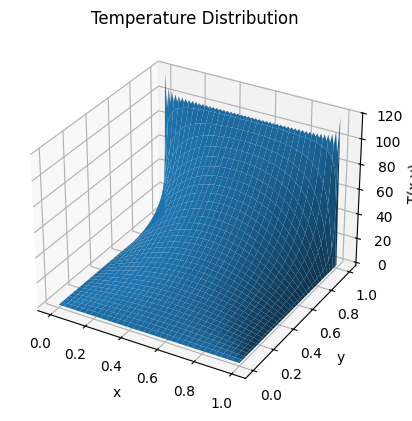

In [24]:
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(x_domain, y_domain)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, T_grid)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('T(x,y)')
ax.set_title('Temperature Distribution')

plt.show()

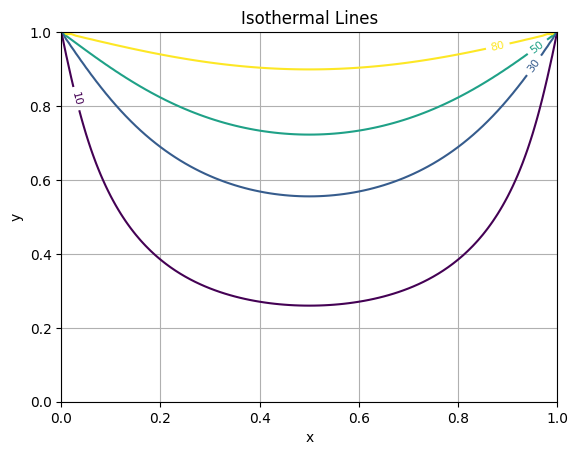

In [25]:
plt.figure()

contours = plt.contour(X, Y, T_grid, levels=[10, 30, 50, 80])

plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Isothermal Lines')

plt.grid()
plt.show()